In [1]:
# imports and settings
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import MDAnalysis as mda
import seaborn as sns
import nglview as nv                            # for visualisation
from MDAnalysis.analysis.align import alignto   # for aligning structures
from MDAnalysis.analysis.pca import PCA         # for PCA
from Bio.PDB import PDBParser
from Bio.PDB.DSSP import DSSP                   # for secondary structure selection
from Bio.PDB.SASA import ShrakeRupley           # for SASA calculation
from IPython.display import display             # for data frame display
from multiprocessing import Pool                # for multiprocessing
from tqdm import tqdm                           # for progress bars

# surpress warnings
warnings.filterwarnings(action='ignore', module='matplotlib')
warnings.filterwarnings(action='ignore', module='mdanalysis')
warnings.filterwarnings('ignore')

# pandas settings
pd.set_option('display.max_colwidth', None)

############################################################################################################

# base directories
base_directory = "/biggin/b212/bioc1781/Projects/PepT/" #"/biggin/b212/bioc1781/Projects/KDELR/red-msa/"  #"/biggin/b212/bioc1781/Projects/CTNS/human/monomer/red-msa/with-dropout/"
structure_directory = base_directory + "ensemble/" # directory with the AF2 ensemble, cannot be the same as base directory

# settings
selection_for_writeout  = "protein and name CA"  # useful if you want all the outputs to have a specific selection
conserved_residues      = "resid 1 or resid 11 or resid 13 or resid 14 or resid 15 or resid 16 or resid 18 or resid 19 or resid 20 or resid 21 or resid 28 or resid 47 or resid 52 or resid 55 or resid 58 or resid 63 or resid 67 or resid 72 or resid 79 or resid 82 or resid 114 or resid 116 or resid 119 or resid 120 or resid 121 or resid 129 or resid 130 or resid 142 or resid 145 or resid 146 or resid 149 or resid 150 or resid 152 or resid 179 or resid 182 or resid 186 or resid 193 or resid 196 or resid 200 or resid 238 or resid 270 or resid 271 or resid 276 or resid 281 or resid 284 or resid 288 or resid 306 or resid 315 or resid 322 or resid 323 or resid 337 or resid 338 or resid 341 or resid 349 or resid 356 or resid 536 or resid 539 or resid 568 or resid 573 or resid 580 or resid 590 or resid 592 or resid 596 or resid 599 or resid 607 or resid 614 or resid 633 or resid 647 or resid 654 or resid 658" #"resid 162 or resid 281 or resid 142 or resid 143 or resid 346 or resid 345 or resid 305 or resid 280 or resid 138 or resid 211 or resid 208 or resid 273 or resid 173 or resid 335 or resid 205 or resid 332 or resid 176 " #"resid 205 or resid 305 or resid 346 or resid 169 or resid 308 or resid 339 or resid 260 or resid 158 or resid 338 or resid 177 or resid 288 or resid 222 or resid 139 or resid 141 or resid 298 or resid 182 or resid 280 or resid 335 or resid 142 or resid 138 or resid 170 or resid 208 or resid 173 or resid 134"        #'resid 205 or resid 305 or resid 346 or resid 169 or resid 308 or resid 339 or resid 260 or resid 158 or resid 338 or resid 177 or resid 288 or resid 222 or resid 139 or resid 141 or resid 298 or resid 182 or resid 280 or resid 335 or resid 142 or resid 138 or resid 170 or resid 208 or resid 173 or resid 134'
excluded_residues       = "resid 363-565"
resid_offset    = 0

# structure filtering   
thresh_rmsd     = 10                # threshold for discarding structures based on RMSD
thresh_pLDDT    = 87                # threshold for discarding structures based on pLDDT
thresh_sasa_coeff = 100             # multiple of highest sasa of the reference structure above which structures are discarded

# for plotting
plot_variable_1     = 'PC1'   
plot_variable_2     = 'PC2'
plot_variable_3     = 'sasa'


# analysis  
num_processes   = 12                # CPU cores to use for multiprocessing
n_pcs           = 3                 # number of principal components to keep in PCA

# monte carlo   
mc_temp         = 500               # monte carlo temperature
mc_wf_sasa      = 0                 # monte carlo energy function weight factor for SASA (check if this should be -ve, depends on order of subtraction and matrix indexing)
mc_n_runs       = 1                 # number of monte carlo runs
mc_n_bins       = 16                # so mc_n_bins is the total number of bins (because of reference structures and zero indexing)
collective_variable = 'PC1'         # collective_variable to bin for path finding
start_from_endstates = False


os.environ["OMP_NUM_THREADS"] = str(num_processes)

############################################################################################################

# reference structures
use_reference_structures = False

if use_reference_structures:

    ## this bit should be as generic as possible (i.e. take a list of N input structures)

    outward_open_pdb = base_directory + "8DKE_cytosol_noNTD_hydrogens.pdb"
    inward_open_pdb  = base_directory + "8DKI_lumen_noNTD_hydrogens.pdb"

    # universes for reference structures
    u_outward_open = mda.Universe(outward_open_pdb, outward_open_pdb)
    u_inward_open  = mda.Universe(inward_open_pdb, inward_open_pdb)

    # align reference structures to eachother
    alignto(u_inward_open, u_outward_open, select='all', weights="mass")

    # write reindexed pdbs of reference structures for inclusion in the ensemble
    u_outward_open.atoms.residues.resids -= resid_offset
    u_outward_open.atoms.write(structure_directory + "ref_outward.pdb")
    u_outward_open.atoms.residues.resids += resid_offset
    #
    u_inward_open.atoms.residues.resids -= resid_offset
    u_inward_open.atoms.write(structure_directory + "ref_inward.pdb")
    u_inward_open.atoms.residues.resids += resid_offset

else:
    outward_open_pdb = None
    inward_open_pdb  = None

reference_pdb = base_directory + "PepT2_3e021_weblogo.pdb"
u = mda.Universe(reference_pdb) # reference universe


In [2]:
# retrieve structures

# user specific - do whatever you need here to get a dictionary of structures and their associated pLDDT values

# # ONLY NEED TO RUN ONCE 
# # copy structures from outputs to ensemble
# msa_depths = ['32-64', '64-128', '128-256', '256-512', '512-1024']
# 
# for msa in msa_depths:
#     structures_msa = [f for f in os.listdir(base_directory + 'output_' + msa) if f.endswith('.pdb')]
#     for structure in structures_msa:
#         # copy all the pdb files with "_relaxed_" in the name to the structure directory
#         if "_relaxed_" in structure:
#             # get the rank of the strcuture (last thing before the file extension)
#             rank = 'rank_' + structure.split('_')[structure.split('_').index('rank')+1]
#             os.system('cp ' + base_directory + 'output_' + msa + '/' + structure + ' ' + structure_directory + '/msa-' + msa + '_' + rank + '.pdb')
# 
# # get list of all files in structure directory directory with the pdb extension
# structures = [f for f in os.listdir(structure_directory) if f.endswith('.pdb')]
# structures.sort()

# associate structures with pLDDT values
structure_and_pLDDT = {}

msa_depths = ['32-64', '64-128', '128-256', '256-512', '512-1024']
for msa in msa_depths:
    structures_msa = [f for f in os.listdir(structure_directory) if f.endswith('.pdb') and msa in f and str(msa) in f]
    log_file = structure_directory + msa + "_log.txt"   # look up the corresponding log file
    for structure in structures_msa:
        rank = 'rank_' + structure.split('_')[structure.split('_').index('rank')+1] # get the rank of the structure
        rank = rank.split('.')[0]           # remove the file extension
        with open(log_file, "r") as file:
            for line in file:               # match the rank with the pLDDT value
                if rank in line:
                    pLDDT = line.split()[3].replace('pLDDT=','')
                    structure_and_pLDDT[structure] = float(pLDDT)
                    break

print('Structures:', len(structure_and_pLDDT))

# if no reference structures, chose 2 hightest pLDDT structures as references
if not use_reference_structures:
    # get the 2 structures with the highest pLDDT values
    ref_structures = sorted(structure_and_pLDDT, key=structure_and_pLDDT.get, reverse=True)[:2]
    print('Reference structures:', ref_structures)
    # declare the appropriate variable (the name of the structure file)
    outward_open_pdb = structure_directory + ref_structures[0]
    inward_open_pdb  = structure_directory + ref_structures[1]
    # universes for reference structures
    u_outward_open = mda.Universe(outward_open_pdb, outward_open_pdb)
    u_inward_open  = mda.Universe(inward_open_pdb, inward_open_pdb)

    # align reference structures to eachother
    alignto(u_inward_open, u_outward_open, select='protein and name CA', weights=None)

    # write reindexed pdbs of reference structures for inclusion in the ensemble
    #u_outward_open.atoms.residues.resids -= resid_offset
    #u_outward_open.atoms.write(structure_directory + "ref_outward.pdb")
    #u_outward_open.atoms.residues.resids += resid_offset
    #
    #u_inward_open.atoms.residues.resids -= resid_offset
    #u_inward_open.atoms.write(structure_directory + "ref_inward.pdb")
    #u_inward_open.atoms.residues.resids += resid_offset


Structures: 10000
Reference structures: ['msa-512-1024_rank_001.pdb', 'msa-64-128_rank_001.pdb']


In [3]:
# automatic "clever" selection definer and make main pandas dataframe and filter data

from ensemblr.smart_selector import generate_selection_token
rmsd_selection = generate_selection_token(reference_pdb, conserved_residues=conserved_residues, excluded_residues=excluded_residues)

check = mda.Universe(reference_pdb).select_atoms(rmsd_selection)
check.write(base_directory + 'rmsd_selection.pdb')


# make main pandas dataframe and filter data
ensemble_df = pd.DataFrame(index=structure_and_pLDDT.keys())
ensemble_df.index.names = ['structure']

pLDDT_scores = {}
plddt_df = pd.DataFrame(list(structure_and_pLDDT.items()), columns=['structure', 'pDDLDT']) # Convert the dictionary to a DataFrame

if use_reference_structures:
    # add entries to dictionary for the reference structures with pLDDT scores of 100
    plddt_df = pd.concat([plddt_df, pd.DataFrame({'structure': 'ref_outward.pdb', 'pDDLDT': 100}, index=[0])], ignore_index=True)   # append is deprecated, use concat instead
    plddt_df = pd.concat([plddt_df, pd.DataFrame({'structure': 'ref_inward.pdb', 'pDDLDT': 100}, index=[0])], ignore_index=True)

# Merge the two DataFrames on the structure column
ensemble_df = pd.merge(ensemble_df, plddt_df, on='structure')

# filter by pLDDT
ensemble_df = ensemble_df[ensemble_df['pDDLDT'] > thresh_pLDDT]      # discard < thresh_pLDDT
structures = list(ensemble_df['structure'])                          # apply the filter to the list of structure names

display(ensemble_df)


,PC1,PC2,PC3,structure
0,-2.698611,-5.809989,0.536606,1151
1,-18.547034,-2.303560,-14.128893,1496
2,-6.585131,-2.085059,-0.062825,2073
3,3.629783,-2.935134,-2.855202,2297
4,-1.598862,-1.454423,-2.557232,2326


,PC cumulated variance
0,54.0
1,63.0
2,69.0
3,73.0
4,77.0


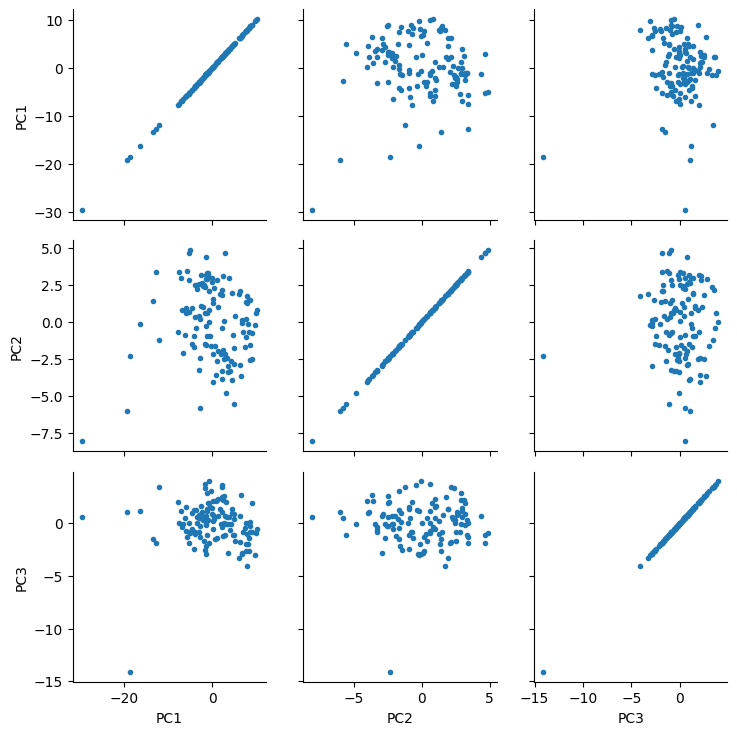

In [5]:
# run PCA on the ensemble

# write a multistate pdb file for the whole ensemble so MDA will interpret it as a trajectory
with mda.Writer(base_directory + 'ensemble.pdb', u.atoms.n_atoms) as W:
    for structure in ensemble_df['structure']:
        u = mda.Universe(structure_directory + structure, 
                         structure_directory + structure)
        # renumber for consistency and to match selection token   s     
        u.atoms.residues.resids += resid_offset
        u.atoms.segments.segids = 'A'
        u.atoms.chainIDs = 'A'
        W.write(u.select_atoms(rmsd_selection))
 
# make a universe containing all the structures
u = mda.Universe(base_directory + "ensemble.pdb")

# align the ensemble to the selection token
aligner = mda.analysis.align.AlignTraj(u, u, select=rmsd_selection, in_memory=True).run()

# perform principal component analysis
pc = PCA(u, select=rmsd_selection, align=True, mean=None, n_components=None).run()

# project coorindates onto the principal components
pc_projection = pc.transform(u.select_atoms(rmsd_selection), n_components=n_pcs)

# make a dataframe to store the principal components
pca_df = pd.DataFrame(pc_projection, columns=['PC{}'.format(i+1) for i in range(n_pcs)])
pca_df['structure'] = ensemble_df.index

# print out the PCs
display(pd.DataFrame(pca_df).head())

# show table of variances explained by each PC
display(pd.DataFrame((pc.cumulated_variance*100).round(), columns=['PC cumulated variance']).head())

#drop the structure column for plotting
pca_df_pairgrid = pca_df.drop('structure', axis=1)
g = sns.PairGrid(pca_df_pairgrid)
g.map(plt.scatter, marker='.')
plt.show()
pca_df_pairgrid = None

# add principal components to the dataframe - making sure the structures are in the same order
pca_df = pca_df.sort_values(by=['structure'])
pca_df = pca_df.reset_index(drop=True)
ensemble_df['PC1'] = pca_df['PC1'].values
ensemble_df['PC2'] = pca_df['PC2'].values
ensemble_df['PC3'] = pca_df['PC3'].values

# visualisation
n_pcs = 3
for i in range(n_pcs):
    pc_n =    pc.p_components[:, i]
    trans_n =   pc_projection[:, i]
    projected = np.outer(trans_n, pc_n) + pc.mean.flatten()
    coordinates = projected.reshape(len(trans_n), -1, 3)
    
    proj_n = mda.Merge(u.select_atoms(rmsd_selection))
    proj_n.load_new(coordinates)
    
    # write this to a multistate pdb file
    with mda.Writer(base_directory + 'pca{}.pdb'.format(i+1), proj_n.atoms.n_atoms) as W:
        for ts in proj_n.trajectory:
            W.write(proj_n.atoms)

Top pLDDT per cluster:


,structure,pDDLDT,PC1,PC2,PC3,cluster
3359,msa-64-128_rank_001.pdb,87.9,-1.143830,0.595006,1.166250,3
4396,msa-128-256_rank_001.pdb,87.9,1.100209,-2.660123,-1.381312,0
4710,msa-128-256_rank_002.pdb,87.9,6.654294,-0.060253,-2.885009,1
8551,msa-512-1024_rank_002.pdb,87.9,-3.817057,0.348198,-1.025783,2
9088,msa-512-1024_rank_004.pdb,87.7,-2.188317,2.469615,0.327688,4
9861,msa-512-1024_rank_005.pdb,87.6,0.205304,1.553241,0.808586,5


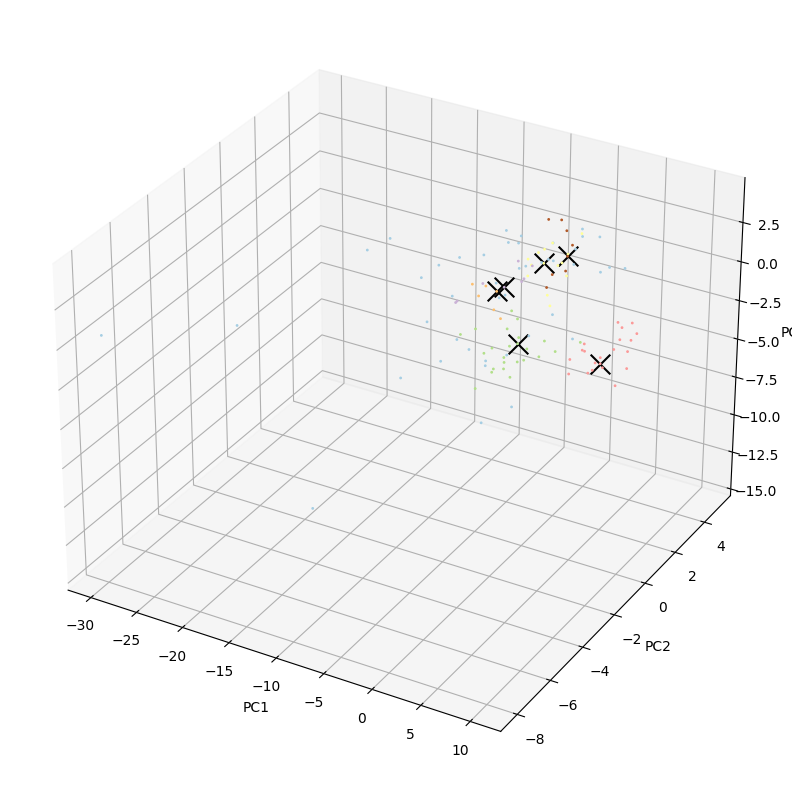

In [6]:
# select references structures for which to perform rmsd calculations below
from sklearn.cluster import HDBSCAN

# min samples is 10 percent of size of ensemble
clustering_min_samples = int(len(ensemble_df) * 0.01)

cluster = HDBSCAN(min_samples=clustering_min_samples, store_centers="medoid").fit(ensemble_df[['PC1', 'PC2', 'PC3']])

# add the cluster labels to the dataframe
ensemble_df['cluster'] = cluster.labels_

# get the number of clusters that are not noise (-1)
num_clusters = len(set(cluster.labels_)) - (1 if -1 in cluster.labels_ else 0)

# plot the clusters
#plt.scatter(ensemble_df['PC1'], ensemble_df['PC2'], c=ensemble_df['cluster'], cmap='viridis')

cluster_representatives = []
for i in cluster.medoids_:
    # lookup the relevant structures in the dataframe (using medoid guarantees this has been sampled)
    cluster_representatives.append(ensemble_df[(ensemble_df['PC1'] == i[0]) & (ensemble_df['PC2'] == i[1]) & (ensemble_df['PC3'] == i[2])]['structure'].values[0])

cluster_best_pLDDT = []
# for each cluster number, get the structure with the highest pLDDT
for i in range(num_clusters):
    cluster_best_pLDDT.append(ensemble_df[ensemble_df['cluster'] == i].sort_values(by=['pDDLDT'], ascending=False)['structure'].values[0])
    
# plot the cluster representatives
#for i in cluster_representatives:
#    plt.scatter(ensemble_df[(ensemble_df['structure'] == i)]['PC1'], ensemble_df[(ensemble_df['structure'] == i)]['PC2'], c='red', marker='x', s=100)

# display the cluster representatives in the dataframe
#print('Cluster centroids (medoids):')
#display(ensemble_df[ensemble_df['structure'].isin(ref_structures)])

# display the best structures per cluster 
print('Top pLDDT per cluster:')
display(ensemble_df[ensemble_df['structure'].isin(cluster_best_pLDDT)].sort_values(by=['pDDLDT'], ascending=False))

ref_structures = cluster_representatives

# diversity pick of structures from the over

xaxis = 'PC1'
yaxis = 'PC2'
zaxis = 'PC3'

# 3D plot of the ensemble
fig = plt.figure(figsize=(10,10))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(ensemble_df[xaxis], ensemble_df[yaxis], ensemble_df[zaxis], c=ensemble_df['cluster'], cmap='Paired', s=1, alpha=1)
# plot the cluster representatives
for i in cluster_representatives:
    ax.scatter(ensemble_df[(ensemble_df['structure'] == i)][xaxis], ensemble_df[(ensemble_df['structure'] == i)][yaxis], ensemble_df[(ensemble_df['structure'] == i)][zaxis], c='black', marker='x', s=200)
ax.set_xlabel(xaxis)
ax.set_ylabel(yaxis)
ax.set_zlabel(zaxis)
plt.show()

In [7]:
# calculate RMSDs of all structures relative to the reference structures

# define function to get rmsd to a structure
def get_rmsd_to_structure(structure):
    mobile = mda.Universe(structure_directory + structure, structure_directory + structure) # make universe
    mobile.atoms.residues.resids += resid_offset                                            # renumber residues in mobile
    rmsds = alignto(mobile, ref, select=rmsd_selection, match_atoms=True, weights=None)     # these ref selections are different becasue ref has different residue numbering
    return [structure, rmsds[1]]                                                            # [1] = rmsd after alignment

# define a function to calculate the SASA of a structure
def get_sasa(structure):
    p = PDBParser(QUIET=1)
    struct = p.get_structure(structure, structure_directory + structure)
    sr = ShrakeRupley(probe_radius=1.4, n_points=100)
    sr.compute(struct, level="S")
    return [structure, struct.sasa]  


if use_reference_structures:

    # get average positions and make new universe with these positions
    average_positions = (u_outward_open.atoms.positions + u_inward_open.atoms.positions) / 2
    u_average = mda.Universe(outward_open_pdb, outward_open_pdb)
    u_average.atoms.positions = average_positions

    rmsd_to_outward = {}

    # outward open
    ref = u_outward_open
    with Pool(processes=num_processes) as pool:
        rmsds = list(tqdm(pool.imap(get_rmsd_to_structure, structures), total=len(structures)))
    rmsd_to_outward = dict(rmsds)   # make this list of tuples into a dictionary

    rmsd_to_inward = {}

    # inward open
    ref = u_inward_open
    with Pool(processes=num_processes) as pool:
        rmsds = list(tqdm(pool.imap(get_rmsd_to_structure, structures), total=len(structures)))
    rmsd_to_inward = dict(rmsds)   # make this list of tuples into a dictionary

    rmsd_to_average = {}

    # average
    ref = u_average
    with Pool(processes=num_processes) as pool:
        rmsds = list(tqdm(pool.imap(get_rmsd_to_structure, structures), total=len(structures)))
    rmsd_to_average = dict(rmsds)   # make this list of tuples into a dictionary

    sasa_dict = {}

    # solvent accesible surface areas
    with Pool(processes=num_processes) as pool:
        sasas = list(tqdm(pool.imap(get_sasa, structures), total=len(structures)))
    sasa_dict = dict(sasas)         # make this list of tuples into a dictionary

    # add the values to the dataframe
    ensemble_df['rmsd_to_outward'] = rmsd_to_outward.values()
    ensemble_df['rmsd_to_inward'] = rmsd_to_inward.values()
    ensemble_df['rmsd_to_average'] = rmsd_to_average.values()
    ensemble_df['sasa'] = sasa_dict.values()

else:

    # get rmsd with respect ot each of hte reference structures (from PCA)
    for ref_structure in ref_structures:
        
        # make a universe with the reference structure
        ref = mda.Universe(structure_directory + ref_structure, structure_directory + ref_structure)

        # get rmsd to reference structure
        rmsds = {}
        with Pool(processes=num_processes) as pool:
            rmsds = list(tqdm(pool.imap(get_rmsd_to_structure, structures), total=len(structures)))
        rmsds = dict(rmsds)

        # add to the dataframe
        ensemble_df['rmsd_to_' + ref_structure] = rmsds.values()

    sasa_dict = {}

    # solvent accesible surface areas
    with Pool(processes=num_processes) as pool:
        sasas = list(tqdm(pool.imap(get_sasa, structures), total=len(structures)))
    sasa_dict = dict(sasas)         # make this list of tuples into a dictionary

    # add the sasa values to the dataframe
    ensemble_df['sasa'] = sasa_dict.values()

display(ensemble_df)

100%|██████████| 125/125 [00:24<00:00,  5.17it/s]


,structure,pDDLDT,PC1,PC2,PC3,cluster,rmsd_to_msa-128-256_rank_006.pdb,rmsd_to_msa-128-256_rank_023.pdb,rmsd_to_msa-128-256_rank_030.pdb,rmsd_to_msa-256-512_rank_007.pdb,rmsd_to_msa-512-1024_rank_004.pdb,rmsd_to_msa-512-1024_rank_020.pdb,sasa
1151,msa-32-64_rank_002.pdb,87.3,-2.698611,-5.809989,0.536606,-1,0.513256,0.643285,0.486072,0.481920,0.536064,0.523979,30619.542487
1496,msa-32-64_rank_001.pdb,87.6,-18.547034,-2.303560,-14.128893,-1,1.245854,1.390476,0.956728,1.024220,1.060549,1.151987,30165.692342
2073,msa-64-128_rank_010.pdb,87.2,-6.585131,-2.085059,-0.062825,-1,0.603508,0.758098,0.393002,0.390551,0.412553,0.514506,30736.512263
2297,msa-64-128_rank_015.pdb,87.1,3.629783,-2.935134,-2.855202,-1,0.362912,0.366729,0.496041,0.459072,0.475761,0.471691,30511.014472
2326,msa-64-128_rank_005.pdb,87.5,-1.598862,-1.454423,-2.557232,-1,0.405286,0.545575,0.357659,0.329476,0.347860,0.374999,30449.867041
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9852,msa-512-1024_rank_028.pdb,87.1,-5.377840,2.849601,-0.853552,-1,0.544430,0.680425,0.322923,0.345794,0.246701,0.339432,30342.896816
9861,msa-512-1024_rank_005.pdb,87.6,0.205304,1.553241,0.808586,5,0.347271,0.455762,0.378600,0.298074,0.231018,0.230012,30547.462237
9864,msa-512-1024_rank_029.pdb,87.1,-1.317293,4.372767,0.718784,4,0.498795,0.549560,0.362257,0.287974,0.313766,0.307260,30833.069741
9984,msa-512-1024_rank_012.pdb,87.4,-1.486075,3.214112,-0.182748,4,0.437027,0.553118,0.308643,0.259798,0.290821,0.300623,30559.099187


In [8]:
# optional - measure certain distances and add them to the dataframe
OF_helix_bundle_1  = ''
OF_helix_bundle_2  = ''
IF_helix_bundle_1 = ''
IF_helix_bundle_2 = ''

# calculate certain distances e.g. to use as a CV
def calc_distance(structure, selection1, selection2):
        universe = mda.Universe(structure_directory + structure, structure_directory + structure) # make universe
        universe.atoms.residues.resids += resid_offset      
        sel1_coords = universe.select_atoms(selection1).positions
        sel2_coords = universe.select_atoms(selection2).positions
        sel1_coords_avg = np.mean(sel1_coords, axis=0)  # geometric average = COM when all atoms are Ca
        sel2_coords_avg = np.mean(sel2_coords, axis=0)  # geometric average = COM when all atoms are Ca
        distance = np.linalg.norm(sel1_coords_avg - sel2_coords_avg)
        return distance

# calculate distances
distances = {}
for structure in structures:
    distances[structure] = calc_distance(structure, cyto_helix_bundle_1, cyto_helix_bundle_2)

# add the distances to the dataframe
ensemble_df['distance_1'] = distances.values()

distances = {}
for structure in structures:
    distances[structure] = calc_distance(structure, lumen_helix_bundle_1, lumen_helix_bundle_2)

# add the distances to the dataframe
ensemble_df['distance_2'] = distances.values()
   
#  show
display(ensemble_df)


NameError: name 'cyto_helix_bundle_1' is not defined

Represnetative structures from each cluster:


,structure,pDDLDT,PC1,PC2
4445,msa-128-256_rank_006.pdb,87.6,3.345496,-2.451659


,structure,pDDLDT,PC1,PC2
5026,msa-128-256_rank_023.pdb,87.3,8.00795,-0.137998


,structure,pDDLDT,PC1,PC2
5238,msa-128-256_rank_030.pdb,87.2,-4.555361,0.952327


,structure,pDDLDT,PC1,PC2
6211,msa-256-512_rank_007.pdb,87.4,-2.892551,0.425831


,structure,pDDLDT,PC1,PC2
9088,msa-512-1024_rank_004.pdb,87.7,-2.188317,2.469615


,structure,pDDLDT,PC1,PC2
8686,msa-512-1024_rank_020.pdb,87.2,-0.102416,2.701558


Lowest 3 SASA:


,structure,cluster,pDDLDT,PC1,PC2
2602,msa-64-128_rank_016.pdb,-1,87.1,-29.622165,-8.038596
4245,msa-128-256_rank_037.pdb,-1,87.2,-19.236897,-5.998996
1496,msa-32-64_rank_001.pdb,-1,87.6,-18.547034,-2.303560


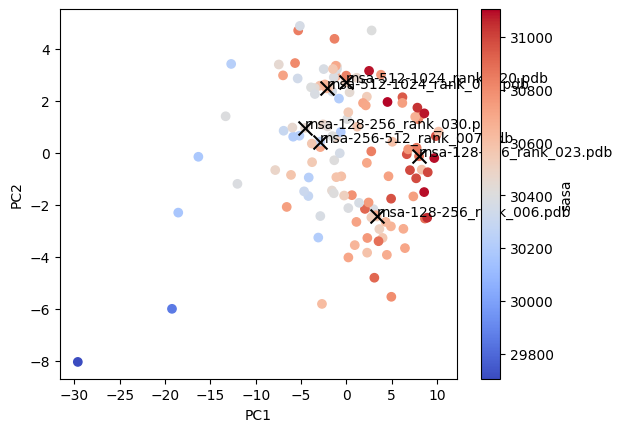

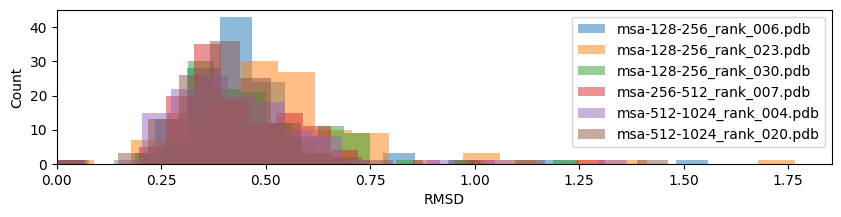

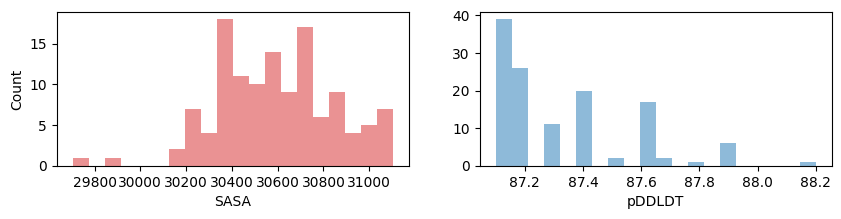

In [9]:
# make plots
if use_reference_structures:

    # display tables of closest to reference structures, lowest sasa, and most different
    print('Closest to outward open:')
    display(ensemble_df.sort_values(by=['rmsd_to_outward']).head(1)[['structure', 'pDDLDT', 'rmsd_to_outward', 'PC1', 'PC2']])
    print('Closest to inward open:')
    display(ensemble_df.sort_values(by=['rmsd_to_inward']).head(1)[['structure', 'pDDLDT', 'rmsd_to_inward', 'PC1', 'PC2']])

    # plot the rmsd to the reference structures
    plt.scatter(ensemble_df['rmsd_to_outward'], ensemble_df['rmsd_to_inward'], c=ensemble_df['pDDLDT'], cmap='coolwarm')
    plt.xlabel('RMSD to outward open')
    plt.ylabel('RMSD to inward open')
    plt.colorbar(label='pLDDT')
    #limits
    plt.xlim(0)
    plt.ylim(0)
    plt.show()

        # plot the rmsd to the reference structures
    plt.scatter(ensemble_df['rmsd_to_outward'], ensemble_df['rmsd_to_inward'], c=ensemble_df['sasa'], cmap='coolwarm')
    plt.xlabel('RMSD to outward open')
    plt.ylabel('RMSD to inward open')
    plt.colorbar(label='SASA')
    plt.show()


    # plot histogram of rmsd to outward open
    plt.hist(ensemble_df['rmsd_to_outward'], bins=20, alpha=0.5, label='outward open')
    plt.hist(ensemble_df['rmsd_to_inward'], bins=20, alpha=0.5, label='inward open')

else:

    # display tables of closest to reference structures, lowest sasa, and most different
    print('Represnetative structures from each cluster:')
    for i in ref_structures:
        display(ensemble_df.sort_values(by=['rmsd_to_' + i]).head(1)[['structure', 'pDDLDT', 'PC1', 'PC2']])
    print('Lowest 3 SASA:')
    display(ensemble_df.sort_values(by=['sasa']).head(3)[['structure', 'cluster', 'pDDLDT', 'PC1', 'PC2']])
    
    
    # plot ensemble
    plt.scatter(ensemble_df[plot_variable_1], ensemble_df[plot_variable_2], c=ensemble_df[plot_variable_3], cmap='coolwarm')
    plt.xlabel(plot_variable_1)
    plt.ylabel(plot_variable_2)
    plt.colorbar(label=plot_variable_3)
    
    # annotate reference structures
    for i in ref_structures:
        plt.scatter(ensemble_df.loc[ensemble_df['structure'] == i][plot_variable_1], ensemble_df.loc[ensemble_df['structure'] == i][plot_variable_2], c='black', marker='x', s=100)
        plt.annotate(i, (ensemble_df.loc[ensemble_df['structure'] == i][plot_variable_1], ensemble_df.loc[ensemble_df['structure'] == i][plot_variable_2]))
    plt.show()
    
    # for each reference structure, plot the histogram of rmsd to that structure
    for i in ref_structures:
        plt.hist(ensemble_df['rmsd_to_' + i], bins=20, alpha=0.5, label=i)
    plt.legend(loc='upper right')
    plt.xlabel('RMSD')
    plt.ylabel('Count')
    plt.xlim(0)
    fig = plt.gcf()
    fig.set_size_inches(10, 2)
    plt.show()
    
    # plot 2 pane histogram of SASA and pLDDT scores
    fig, (ax1, ax2) = plt.subplots(1, 2)
    ax1.hist(ensemble_df['sasa'], bins=20, alpha=0.5, label='sasa', color='C3')
    ax1.set_xlabel('SASA')
    ax1.set_ylabel('Count')
    ax2.hist(ensemble_df['pDDLDT'], bins=20, alpha=0.5, label='pDDLDT')
    ax2.set_xlabel('pDDLDT')
    fig = plt.gcf()
    fig.set_size_inches(10, 2)
    plt.show()


An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


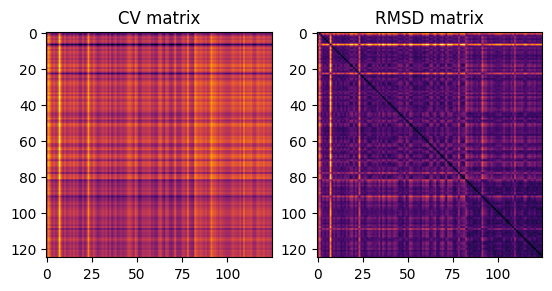

In [10]:
# calculate property matrices for Monte Carlo simulated annealing

from ensemblr.calc_matrices import pdb_to_coordinates, get_rmsdmat_jax, get_diffmat

rmsd_matrix = get_rmsdmat_jax(pdb_to_coordinates(base_directory + 'ensemble.pdb'), ensemble_df)
cv_matrix = get_diffmat(ensemble_df, collective_variable)

# show for inspection
fig, (ax1, ax2) = plt.subplots(1, 2)
ax1.imshow(cv_matrix, cmap='inferno')
ax1.set_title('CV matrix')
ax2.imshow(rmsd_matrix, cmap='inferno')
ax2.set_title('RMSD matrix')
plt.show()

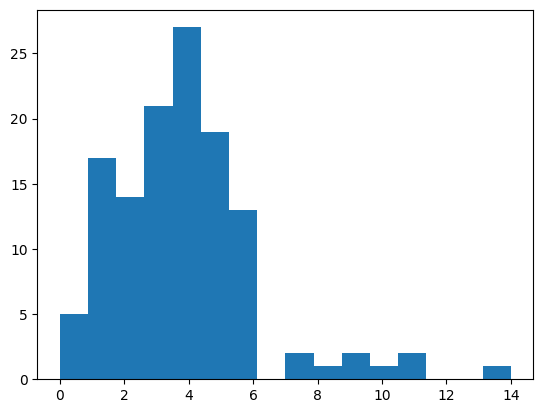

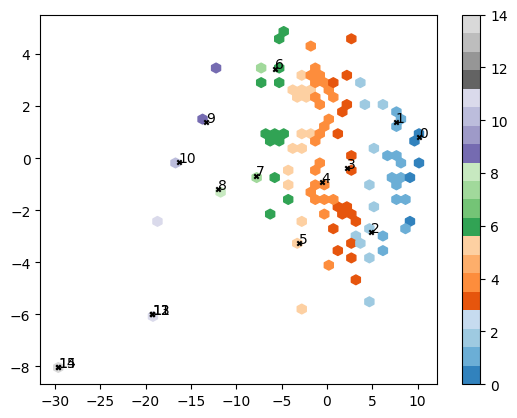

In [11]:
# assign bins for binned mc path finding

use_defined_end_states = False

occluded_state = 'msa-64-128_rank_1142.pdb'
#lumen_open 'msa-128-256_rank_1163.pdb'
#cyto open 'msa-32-64_rank_127.pdb'

# end states to interpolate between values of the CV of
end_state_1 = 'msa-32-64_rank_1297.pdb' #'msa-32-64_rank_127.pdb' #'' #msa-128-256_rank_1163.pdb
end_state_2 = occluded_state

if use_defined_end_states == True:
    max_value = end_state_1_cv_value
    min_value = end_state_2_cv_value

    # get the values of the CV for these structures
    end_state_1_cv_value = ensemble_df[ensemble_df['structure'] == end_state_1][collective_variable].values[0]
    end_state_2_cv_value = ensemble_df[ensemble_df['structure'] == end_state_2][collective_variable].values[0]

else:
    # just get the min and max value of the end states globally, like before
    max_value = ensemble_df[collective_variable].max()
    min_value = ensemble_df[collective_variable].min()


## get the ideal collective variable values per window between min and max_value using linear interpolation
ideal_window_values = np.zeros(mc_n_bins)
for i in range(mc_n_bins):
    ideal_window_values[i] = np.interp(i, [0, mc_n_bins-1], [max_value, min_value])
ideal_initial_path = []
for i in ideal_window_values:
    ideal_initial_path.append(ensemble_df[collective_variable].sub(i).abs().idxmin())

# replace the first and last structures in the ideal path with the end states
if use_defined_end_states == True:
    ideal_initial_path[0] = ensemble_df[ensemble_df['structure'] == end_state_1].index[0]
    ideal_initial_path[-1] = ensemble_df[ensemble_df['structure'] == end_state_2].index[0]

## set up the bins for the binned path
ensemble_df['closest_ideal_structure'] = ensemble_df[collective_variable].apply(lambda x: ideal_initial_path[np.argmin(np.abs(ideal_window_values - x))])
ensemble_df['bin'] = ensemble_df['closest_ideal_structure'].apply(lambda x: ideal_initial_path.index(x))


# plotting
#display(ensemble_df)
plt.hist(ensemble_df['bin'], bins=mc_n_bins)
plt.show()

# show bin distribution
plt.hexbin(ensemble_df[plot_variable_1], ensemble_df[plot_variable_2], C=ensemble_df['bin'], cmap='tab20c', gridsize=40, reduce_C_function=np.amax)
#plt.scatter(ensemble_df[plot_variable_1], ensemble_df[plot_variable_2], c=ensemble_df['bin'], cmap='tab20c')
plt.colorbar()

# plot the initial guesses
for i in range(mc_n_bins):
    plt.scatter(ensemble_df.loc[ensemble_df.index == ideal_initial_path[i]][plot_variable_1], ensemble_df.loc[ensemble_df.index == ideal_initial_path[i]][plot_variable_2], marker='x', color='black', s=10)
# label the ideal structures wit htheir associated bin
for i in range(mc_n_bins):
    plt.annotate(i, (ensemble_df.loc[ensemble_df.index == ideal_initial_path[i]][plot_variable_1], ensemble_df.loc[ensemble_df.index == ideal_initial_path[i]][plot_variable_2]))

plt.show()

100%|██████████| 100/100 [00:00<00:00, 896218.80it/s]


,energy,path structures
49,3.765807,"(msa-128-256_rank_025.pdb, msa-256-512_rank_010.pdb, msa-256-512_rank_004.pdb, msa-512-1024_rank_010.pdb, msa-512-1024_rank_020.pdb, msa-512-1024_rank_034.pdb, msa-512-1024_rank_028.pdb, msa-512-1024_rank_031.pdb, msa-256-512_rank_011.pdb, msa-512-1024_rank_036.pdb, msa-512-1024_rank_033.pdb, msa-128-256_rank_037.pdb, msa-128-256_rank_037.pdb, msa-128-256_rank_037.pdb, msa-64-128_rank_016.pdb, msa-64-128_rank_016.pdb)"
39,3.765807,"(msa-128-256_rank_025.pdb, msa-256-512_rank_010.pdb, msa-256-512_rank_004.pdb, msa-512-1024_rank_010.pdb, msa-512-1024_rank_020.pdb, msa-512-1024_rank_034.pdb, msa-512-1024_rank_028.pdb, msa-512-1024_rank_031.pdb, msa-256-512_rank_011.pdb, msa-512-1024_rank_036.pdb, msa-512-1024_rank_033.pdb, msa-128-256_rank_037.pdb, msa-128-256_rank_037.pdb, msa-128-256_rank_037.pdb, msa-64-128_rank_016.pdb, msa-64-128_rank_016.pdb)"
38,3.765807,"(msa-128-256_rank_025.pdb, msa-256-512_rank_010.pdb, msa-256-512_rank_004.pdb, msa-512-1024_rank_010.pdb, msa-512-1024_rank_020.pdb, msa-512-1024_rank_034.pdb, msa-512-1024_rank_028.pdb, msa-512-1024_rank_031.pdb, msa-256-512_rank_011.pdb, msa-512-1024_rank_036.pdb, msa-512-1024_rank_033.pdb, msa-128-256_rank_037.pdb, msa-128-256_rank_037.pdb, msa-128-256_rank_037.pdb, msa-64-128_rank_016.pdb, msa-64-128_rank_016.pdb)"


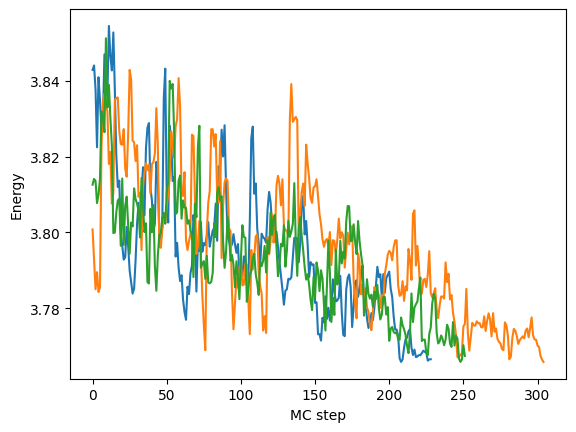

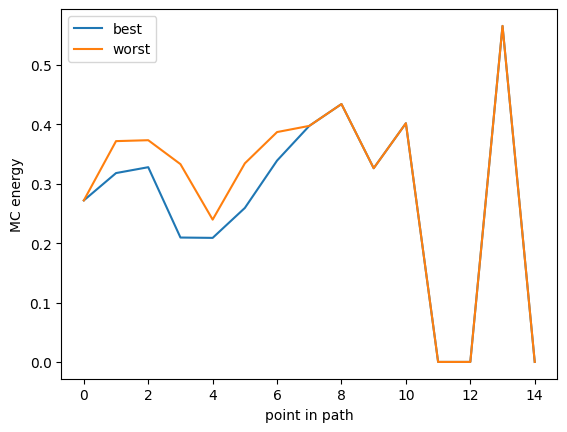

In [22]:
# MC path finding by exchanging structures within bins

from ensemblr.monte_carlo import mc_path_optimisation

reproducible_seed = True
mc_n_runs = 100

if reproducible_seed:
    # reproducible version
    with Pool(processes=num_processes) as pool:
        # parallel execution
        mc_runs = list(tqdm(pool.starmap(mc_path_optimisation, zip(range(mc_n_runs), [ideal_initial_path]*mc_n_runs, [rmsd_matrix]*mc_n_runs, [cv_matrix]*mc_n_runs, [ensemble_df]*mc_n_runs)), total=mc_n_runs))
#else:
#    # re-randomised, non-reproducible version
#    seeds = np.random.randint(low=0, high=1e3, size=mc_n_runs)  # Create a list of random seeds
#    with Pool(processes=num_processes) as pool:
#        mc_runs = list(tqdm(pool.imap(mc_path_optimisation, zip(range(mc_n_runs), seeds)), total=mc_n_runs))     

# add the final energies and final path structures to a dataframe
mc_runs_df = pd.DataFrame(mc_runs, columns=['energy', 'path', 'path structures', 'relaxation energies'])
mc_runs_df = mc_runs_df.sort_values(by=['energy']) 


### plotting ###


# display the best run
display(mc_runs_df[['energy', 'path structures']].head(3))

# plot relaxation of the best run
for i in range(1, 4):
    plt.plot(mc_runs_df.iloc[i]['relaxation energies'])
plt.xlabel('MC step')
plt.ylabel('Energy')
plt.show()

# calculate the energy for each point in the best path (mc_runs[1]) (for plotting)
energy_over_path = []
energy = {}

# re-calcualte the energy over the final path and plot for inspection
test = mc_runs_df.iloc[0]['path']
for i in range(mc_n_bins - 1):
        energy[i] = (rmsd_matrix[np.where(ensemble_df.index.values == test[i])[0][0], np.where(ensemble_df.index.values == test[i+1])[0][0]]**2)
        energy[i] = np.sqrt ( 1 * energy[i] )
plt.plot(energy.values(), label='best')
test = mc_runs_df.iloc[-1]['path']
for i in range(mc_n_bins - 1):
        energy[i] = (rmsd_matrix[np.where(ensemble_df.index.values == test[i])[0][0], np.where(ensemble_df.index.values == test[i+1])[0][0]]**2)
        energy[i] = np.sqrt ( 1 * energy[i] )
plt.plot(energy.values(), label='worst')
plt.legend()
plt.xlabel('point in path')
plt.ylabel('MC energy')
plt.show()

# write out the best run to a multistate pdb file and append timestamp to filename
with mda.Writer(base_directory + 'best_run.pdb', u.atoms.n_atoms) as W:
    # get the structures of the lowest energy path
    for structure in mc_runs_df.head(1)['path structures'].values[0]:
        # if structure is the reference, dont renumber residues
        if structure == 'ref_outward.pdb' or structure == 'ref_inward.pdb':
            # use a non-reference structure to make the universe
            u = mda.Universe(structure_directory + structure, 
                             structure_directory + structure) # make universe
            u.atoms.residues.resids += resid_offset 
            u.atoms.segments.segids = 'A'
            u.atoms.chainIDs = 'A'
            W.write(u.select_atoms('protein'))
        else:
            u = mda.Universe(structure_directory + structure, 
                             structure_directory + structure) # make universe
            u.atoms.residues.resids += resid_offset
            W.write(u.select_atoms('protein'))

In [ ]:
# plot the best path

# plot all the structures
plt.hexbin(ensemble_df[plot_variable_1], ensemble_df[plot_variable_2], C=ensemble_df['bin'], cmap='tab20c', gridsize=40, reduce_C_function=np.amax)
#
#plt.scatter(ensemble_df[plot_variable_1], ensemble_df[plot_variable_2], c=ensemble_df['bin'], cmap='tab20c', alpha=0.8, s=2)
# plot all the structures as a hexgrid 


# for each structure in best run, plot the rmsd to outward and inward from the ensemble_df dataframe
for structure in mc_runs_df.head(1)['path'].values[0]:
    plt.scatter(ensemble_df.loc[structure][plot_variable_1], ensemble_df.loc[structure][plot_variable_2], c='black', s=32)
    # annotate them with their bin number
    #plt.annotate(ensemble_df.loc[structure]['bin'], (ensemble_df.loc[structure][plot_variable_1], ensemble_df.loc[structure][plot_variable_2]), xytext=(ensemble_df.loc[structure][plot_variable_1], ensemble_df.loc[structure][plot_variable_2]+0.5), ha='center', va='bottom', arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0.2'))

# draw connecting lines
for i in range(len(mc_runs_df.head(1)['path'].values[0]) - 1):
    # get the rmsd to outward and inward from ensemble_df
    x1 = ensemble_df.loc[mc_runs_df.head(1)['path'].values[0][i]][plot_variable_1]
    y1 = ensemble_df.loc[mc_runs_df.head(1)['path'].values[0][i]][plot_variable_2]
    x2 = ensemble_df.loc[mc_runs_df.head(1)['path'].values[0][i+1]][plot_variable_1]
    y2 = ensemble_df.loc[mc_runs_df.head(1)['path'].values[0][i+1]][plot_variable_2]
    plt.plot([x1, x2], [y1, y2], c='black', alpha=0.6, linestyle='dashed')

# plot the initial guesses
#for i in range(mc_n_bins):
#    plt.scatter(ensemble_df.loc[ensemble_df.index == ideal_initial_path[i]][plot_variable_1], ensemble_df.loc[ensemble_df.index == ideal_initial_path[i]][plot_variable_2], marker='x', color='black', s=10)

#display(mc_runs_df.head(1))
#display(mc_runs_df.tail(1))

plt.xlabel(plot_variable_1)
plt.ylabel(plot_variable_2)
plt.show()

# Plot how good this is

# plot the ideal window values
plt.plot(ideal_window_values, label='ideal', color='black', alpha=0.2)
# show dots
plt.scatter(range(mc_n_bins), ideal_window_values, c=range(mc_n_bins), cmap='coolwarm', alpha=0.5)

# get the actual values
actual_window_values = np.zeros(mc_n_bins)
for i in range(mc_n_bins):
    actual_window_values[i] = ensemble_df.loc[mc_runs_df.head(1)['path'].values[0][i]][collective_variable]

## print the ideal and actual values in a table (rounded to 2 decimal places)
#print(pd.DataFrame({'ideal': ideal_window_values, 'actual': actual_window_values}).round(2))

# plot the actual values
plt.plot(actual_window_values, label='actual', c='black', alpha=0.8)
# show dots
plt.scatter(range(mc_n_bins), actual_window_values, c=range(mc_n_bins), cmap='coolwarm')

# plot vertical lines between the two
for i in range(mc_n_bins):
    plt.plot([i, i], [ideal_window_values[i], actual_window_values[i]], c='black', alpha=0.2, linestyle='dashed')

if ideal_initial_path == True:

    # alternate where initial guessi ncides are just those of the structures closest to the ideal values of the collective variable (from a linear interpolation)
    initial_guess_indices = []
    # get the ideal values of the collective variable

    # enpoint values are min adn max of the collective variable
    ideal_values = np.linspace(ensemble_df[collective_variable].min(), ensemble_df[collective_variable].max(), mc_n_bins)

    # get the closest structure to each ideal value
    for i in ideal_values:
        initial_guess_indices.append(ensemble_df[collective_variable].sub(i).abs().idxmin())
    # plot the initial guesses
    for i in range(mc_n_bins):
        plt.scatter(i, ensemble_df.loc[initial_guess_indices[i]][collective_variable], marker='x', color='black')
    print(len(initial_guess_indices))   

# x axis labels
plt.xticks(range(mc_n_bins), range(mc_n_bins))
plt.xlabel('Window Number')
plt.ylabel(collective_variable + 'CV')
plt.legend()

# add a title
plt.title('Ideal vs Actual Window CV Values')
plt.show()

# now just plot the offsets (absolute) as a bar chart
offsets = np.abs(ideal_window_values - actual_window_values)
plt.bar(range(mc_n_bins), offsets, color='black', alpha=0.2)
plt.xlabel('Window Number')
plt.ylabel('Absolute Offset')
plt.title('how good is the path?')
plt.show()


In [ ]:
# set up umbrella sampling windows (for REUS)
from MDAnalysis.analysis import align, rms
import shutil
from difflib import SequenceMatcher

def write_pca_ref_pdb():

    # write a file like pca1.pdb but with "REMARK TYPE=OPTIMAL" after each ENDMDL line
    # edit this file to add "REMARK TYPE=OPTIMAL" after each ENDMDL line
    with open(umbrella_sampling_directory + 'pca_ref.pdb', 'r') as file :
        filedata = file.read()
    # Replace the target string
    filedata = filedata.replace('ENDMDL', 'ENDMDL\nREMARK TYPE=OPTIMAL')
    # Write the file out again
    with open(umbrella_sampling_directory + 'pca_ref.pdb', 'w') as file:
        file.write(filedata)

# function to calculate the similarity between two strings
def similar(a, b):
    return SequenceMatcher(None, a, b).ratio()

# this should be a pdb from e.g. an unbiased simulation you've run before
# containing everything in the simualtion box, protein, lipids, water etc. 
# if you have a working topolgy for this system, you can re-use it here
template_pdb_for_umbrella_sampling = (base_directory + 'template_K273n_smallbilayer.pdb') 

# make a universe from this template
u_template = mda.Universe(template_pdb_for_umbrella_sampling, template_pdb_for_umbrella_sampling)

# sort out your collective variable, for later inclusion in the
# automatically generated plumed input file
print('collective variable is:', collective_variable, '\n')
if collective_variable == 'cyto_helix_bundle_separation':
    com1 = cyto_helix_bundle_1
    com2 = cyto_helix_bundle_2
    pcavar = False
elif collective_variable == 'lumen_helix_bundle_separation':
    com1 = lumen_helix_bundle_1
    com2 = lumen_helix_bundle_2
    pcavar = False
elif collective_variable == 'PC1':
    com1 = None
    com2 = None
    pcavar = True
    write_pca_ref_pdb()
    pca_ref_pdb = umbrella_sampling_directory + 'pca_ref.pdb'
else:
    print('I dont know what your collective variable is supposed to be, sort this out yourself (thinking emoji)')
    com1 = '{your atoms here}'
    com2 = '{your atoms here}'
    pcavar = False


# align a mobile universe to a reference universe
def align_universe(mobile, ref):
# aligns mobile universe to first frame of reference universe
    alignment_selection = 'protein and name CA'
    mobile.trajectory[-1]  # set mobile trajectory to last frame
    ref.trajectory[0]  # set reference trajectory to first frame
    mobile_ca = mobile.select_atoms(alignment_selection)
    ref_ca = ref.select_atoms(alignment_selection)
    rms.rmsd(
             mobile_ca.positions, 
             ref_ca.positions, 
             superposition=False
             )
    aligner = align.AlignTraj(mobile, 
                              ref, 
                              select=alignment_selection,
                              in_memory=True).run()
    return mobile

# replace the protein coordinates in your template with those from a structure in the ensemble
def protein_coordinate_replacer(u_structure, u_template):

    # dictionary of name matches for charmm36 (and I assume amber)
    # key is the name in the template universe, value is the name in the structure universe
    name_mismatches = {
    'ALA HN'   : 'H',
    'ARG HB1'  : 'HB2',
    'ARG HB2'  : 'HB3',
    'ARG HD1'  : 'HD2',
    'ARG HD2'  : 'HD3',
    'ARG HG1'  : 'HG2',
    'ARG HG2'  : 'HG3',
    'ARG HN'   : 'H',
    'ASN HB1'  : 'HB2',
    'ASN HB2'  : 'HB3',
    'ASN HN'   : 'H',
    'ASP HB1'  : 'HB2',
    'ASP HB2'  : 'HB3',
    'ASP HN'   : 'H',
    'CYS HB1'  : 'HB2',
    'CYS HB2'  : 'HB3',
    'CYS HG1'  : 'HG',
    'CYS HN'   : 'H',
    'GLN HB1'  : 'HB2',
    'GLN HB2'  : 'HB3',
    'GLN HG1'  : 'HG2',
    'GLN HG2'  : 'HG3',
    'GLN HN'   : 'H',
    'GLU HB1'  : 'HB2',
    'GLU HB2'  : 'HB3',
    'GLU HG1'  : 'HG2',
    'GLU HG2'  : 'HG3',
    'GLU HN'   : 'H',
    'GLY HA1'  : 'HA2',
    'GLY HA2'  : 'HA3',
    'GLY HN'   : 'H',
    'HSD HB1'  : 'HB2',
    'HSD HB2'  : 'HB3',
    'HSD HN'   : 'H',
    'LEU HN'   : 'H',
    'LYS HB1'  : 'HB2',
    'LYS HB2'  : 'HB3',   
    'LYS HD1'  : 'HD2',
    'LYS HD2'  : 'HD3',
    'LYS HE1'  : 'HE2',
    'LYS HE2'  : 'HE3',
    'LYS HG1'  : 'HG2',
    'LYS HG2'  : 'HG3',
    'LYS HN'   : 'H',
    'MET HB1'  : 'HB2',
    'MET HB2'  : 'HB3',
    'MET HG1'  : 'HG2',
    'MET HG2'  : 'HG3',
    'MET HN'   : 'H',
    'PHE HB1'  : 'HB2',
    'PHE HB2'  : 'HB3',
    'PHE HN'   : 'H',
    'PRO HB1'  : 'HB2',
    'PRO HB2'  : 'HB3',
    'PRO HD1'  : 'HD2',
    'PRO HD2'  : 'HD3',
    'PRO HG1'  : 'HG2',
    'PRO HG2'  : 'HG3',
    'SER HB1'  : 'HB2',
    'SER HB2'  : 'HB3',
    'SER HG1'  : 'HG',
    'SER HN'   : 'H',
    'THR HN'   : 'H',
    'TRP HB1'  : 'HB2',
    'TRP HB2'  : 'HB3',
    'TRP HN'   : 'H',
    'TYR HB1'  : 'HB2',
    'TYR HB2'  : 'HB3',
    'TYR HN'   : 'H',
    'ILE CD'   : 'CD1',
    'ILE HD1'  : 'HD11',
    'ILE HD2'  : 'HD12',
    'ILE HD3'  : 'HD13', 
    'ILE HG11' : 'HG12',
    'ILE HG12' : 'HG13',
    'ILE HN'   : 'H',
    'LEU HB1' : 'HB2',
    'LEU HB1' : 'HB2',
    'VAL HN'  : 'H',
    }


    error_counter = 0
    error_type_list = []

    # renumber the residues in the structure universe
    u_structure.atoms.residues.resids += resid_offset

    # dict to keep track of which atoms in the structure universe have been accounted for (residue: atom)
    modified_atoms = []

    # loop though each atom in the template universe matching the atom name and residue ID to the atom in the template universe
    for atom in u_template.select_atoms('protein').atoms:

        atom_name_template = atom.name

        # if name is in the name_mismatches dictionary, search for the replacement name
        if (atom.resname + ' ' + atom.name) in name_mismatches.keys():
            #print('mismatched atom name: ', atom.name, 'in residue: ', atom.resname, 'replacing with: ', name_mismatches[(atom.resname + ' ' + atom.name)])
            atom_name_template = name_mismatches[(atom.resname + ' ' + atom.name)]

        # match atom with same name and residue ID in the structure universe (from AF ensemble)
        atom_name_structure = u_structure.atoms[(u_structure.atoms.names == atom_name_template) & (u_structure.atoms.resids == atom.resid) ].names

        # if the atom is found in the structure universe, replace the coordinates
        if len(atom_name_structure) > 0:

            # replace the coordinates of the atom in the template universe with the coordinates of the atom in the structure universe
            atom.position = u_structure.atoms[(u_structure.atoms.names == atom_name_template) & (u_structure.atoms.resids == atom.resid) ].positions

            # append the atom to a list of atoms
            modified_atoms.append((str(atom.resid) + str(atom.name)))

        else:
            print('ERROR: with: ', atom.name, atom.resname)

            # add this to a list of resname atom name pairs that are not found in the structure universe
            error_type_list.append((atom.resname, atom.name))

            error_counter += 1
            # handle mismatching atoms 

            # check that the residue itself is present
            if atom.resid in u_structure.atoms.resids:              # if the resid for this missing atom is in the structure universe

                pass
                #print('no atom in resid', atom.resid, atom.resname, 'with name: ', atom.name, 'found')
            
                #    # get the average position of the atoms in the structure universe with the same resid
                #    incomplete_resid_average_position_structure = np.mean(u_structure.atoms[u_structure.atoms.resids == atom.resid].positions, axis=0)
                #    # get the average position of the atoms in the template universe with the same resid
                #    incomplete_resid_average_position_template = np.mean(u_template.atoms[u_template.atoms.resids == atom.resid].positions, axis=0) 
                #    # get the vector between the two averages
                #    fudge_position_vector = incomplete_resid_average_position_structure - incomplete_resid_average_position_template
                #    # add the vector to the atom position in the template universe
                #    atom.position = atom.position + fudge_position_vector

            else:
                print('ERROR: resid not found in structure universe: ', atom.resid)

    print('number of atoms not found in structure universe: ', error_counter)
    # print unique error types in the list
    display(set(error_type_list))
    return u_template.atoms.positions # not important becauase the universe is modified in place, just return something

# turns your mda selection token into a safe list of atom IDs to pass to PLUMED
# because MOLINFO may or may not work depending on what python interpreter
# you have available at runtime
def selection_parser(mda_selection):
    selection_string = ''
    for i in u_template.select_atoms(mda_selection).atoms.ids:
        selection_string += str(i) + ','
    selection_string = selection_string[:-1]
    return selection_string

# write a plumed input file for REUS, if your CV is not a distance then
# you will need to modify this script appropriately
def plumed_input_writer(window_values, plumed_file, force_constant=1000):

    # convert window values to nm (from Angstrom)
    window_values = window_values / 10

    with open(plumed_file, 'w') as f:
        f.write('MOLINFO STRUCTURE=%s \n\n' % template_pdb_for_umbrella_sampling) #window_0/window_0.pdb
        if pcavar == True:
            f.write('CV: PCAVARS REFERENCE=%s TYPE=OPTIMAL\n\n' % pca_ref_pdb) #{@mda:{}}
        else:
            f.write('com1: CENTER ATOMS=%s \n' % selection_parser(com1)) #{@mda:{}}
            f.write('com2: CENTER ATOMS=%s \n' % selection_parser(com2)) #{@mda:{}}
            f.write('\n')
            f.write('CV: DISTANCE ATOMS=com1,com2 \n\n')
        f.write('umbrella_restraint: RESTRAINT ARG=CV KAPPA=%s AT=@replicas:' % force_constant)
        for i in window_values:
            # should be no comma after the last value
            if i == window_values[-1]:
                f.write(str(i.round(4)) + '\n')
            else:
                f.write(str(i.round(4)) + ',')
        f.write('\nPRINT ARG=CV,umbrella_restraint.* FILE=COLVAR_MULTI\n')
        f.write('\n')

# prepare directories for each window
umbrella_sampling_directory = base_directory + 'umbrella_sampling/'
window_directories = []
for i in range(mc_n_bins):
    window_directories.append(umbrella_sampling_directory + 'window_' + str(i))
    if not os.path.exists(window_directories[i]):
        os.makedirs(window_directories[i])
    shutil.copy(structure_directory + mc_runs_df.head(1)['path structures'].values[0][i], window_directories[i])    # copy the relevant structure in mc_runs_df to the window directory

# for each window, replace the coordinates of the protein in the template universe with the coordinates of the structure at the corresponding index in the best path
for i in range(mc_n_bins):

    # make a copy of the template universe
    u = u_template.copy()

    # make a universe out of the structure corresponding to the index in the best path
    structure = mc_runs_df.head(1)['path structures'].values[0][i]
    u_structure = mda.Universe(structure_directory + structure, structure_directory + structure)

    # align the structure to the template universe
    u_structure = align_universe(u_structure, u)
    new_coordinates = protein_coordinate_replacer(u_structure, u)

    # write out the universe to a pdb file
    u.atoms.write(window_directories[i] + '/window_' + str(i) + '.pdb')

# write out the plumed input file
plumed_input_writer(ideal_window_values, umbrella_sampling_directory + '/plumed.dat')